# cam-structural-harmony — Full Pipeline Demo

This notebook demonstrates the complete `cam_harmony` API using **synthetic data** —
no FreeSurfer installation or real MRI data required.

The flow mirrors the production pipeline:
```
Synthetic volumes  →  Intensity normalisation  →  NeuroCombat harmonisation
    →  Variance decomposition (ICC, CV, sources)  →  Figures  →  QC report
```

Steps that require external tools (SynthStrip, ROBEX, FreeSurfer recon-all) are
stubbed out with synthetic outputs so you can see expected data shapes and formats.

In [1]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import tempfile
from pathlib import Path

rng = np.random.default_rng(42)
TMPDIR = Path(tempfile.mkdtemp())
print('cam-structural-harmony demo — imports OK')

cam-structural-harmony demo — imports OK


## Step 1 — Synthetic brain volumes

We create small 3-D arrays (32×32×32 voxels) with a realistic intensity profile:
background near zero, WM peak around 900 HU, GM around 600 HU.  
Affine is set to 3 mm isotropic so nibabel accepts them as valid NIfTI images.

In [2]:
def make_synthetic_t1w(seed: int = 0, scanner_bias: float = 0.0) -> nib.Nifti1Image:
    """Return a 32^3 synthetic T1w with a simple WM/GM/CSF intensity model."""
    rng_local = np.random.default_rng(seed)
    vol = np.zeros((32, 32, 32), dtype=np.float32)

    # Background
    vol[:] = rng_local.normal(5, 2, vol.shape).clip(0)

    # Simulated brain region (central cube)
    brain = vol[8:24, 8:24, 8:24]
    brain[:] = rng_local.normal(600, 80, brain.shape).clip(100)   # GM

    # WM core
    wm = vol[12:20, 12:20, 12:20]
    wm[:] = rng_local.normal(900 + scanner_bias, 60, wm.shape).clip(300)

    affine = np.diag([3.0, 3.0, 3.0, 1.0])
    return nib.Nifti1Image(vol, affine)

N_SUBJECTS = 10
# Simulate two scanners with a 15% intensity offset
scanner_biases = [0.0] * 5 + [135.0] * 5   # subjects 0-4: Scanner A; 5-9: Scanner B

imgs = [make_synthetic_t1w(seed=i, scanner_bias=b) for i, b in enumerate(scanner_biases)]
img_paths = []
for i, img in enumerate(imgs):
    p = TMPDIR / f'sub-{i+1:02d}_T1w.nii.gz'
    nib.save(img, p)
    img_paths.append(p)

print(f'Created {N_SUBJECTS} synthetic T1w volumes — shape {imgs[0].shape}, dtype {imgs[0].get_data_dtype()}')
print(f'Intensity range (sub-01): {imgs[0].get_fdata().min():.1f} – {imgs[0].get_fdata().max():.1f}')

Created 10 synthetic T1w volumes — shape (32, 32, 32), dtype float32
Intensity range (sub-01): 0.0 – 1076.0


## Step 2 — Intensity normalisation

We demonstrate `batch_normalize` with the `zscore` method (individual) and
`minmax` as the naive baseline.  The `nyul` and `fcm_wm` population methods
work the same way — just pass `method='nyul'` etc.

> **Note**: the `intensity-normalization` package must be installed
> (`pip install intensity-normalization`). The calls below show the exact
> API used by the production pipeline.

In [3]:
from cam_harmony.intensity_norm import batch_normalize

norm_dir = TMPDIR / 'minmax'
norm_paths = batch_normalize(img_paths, method='minmax', output_dir=norm_dir)
print(f'\nNormalised {len(norm_paths)} images → {norm_dir}/')

# Show that normalisation reduces the scanner intensity gap
def wm_mean(img: nib.Nifti1Image) -> float:
    d = img.get_fdata()
    return float(d[12:20, 12:20, 12:20].mean())

pre_wm_A  = [wm_mean(imgs[i]) for i in range(5)]
pre_wm_B  = [wm_mean(imgs[i]) for i in range(5, 10)]
post_wm_A = [wm_mean(nib.load(norm_paths[i])) for i in range(5)]
post_wm_B = [wm_mean(nib.load(norm_paths[i])) for i in range(5, 10)]

print(f'Pre-norm WM mean  (Scanner A): {np.mean(pre_wm_A):.1f}  ± {np.std(pre_wm_A):.1f}')
print(f'Pre-norm WM mean  (Scanner B): {np.mean(pre_wm_B):.1f} ± {np.std(pre_wm_B):.1f}')
print(f'Post-norm WM mean (minmax, A): {np.mean(post_wm_A):.3f}  ± {np.std(post_wm_A):.3f}')
print(f'Post-norm WM mean (minmax, B): {np.mean(post_wm_B):.3f}  ± {np.std(post_wm_B):.3f}')

[minmax] Saved: sub-01_T1w.nii.gz
[minmax] Saved: sub-02_T1w.nii.gz
[minmax] Saved: sub-03_T1w.nii.gz
[minmax] Saved: sub-04_T1w.nii.gz
[minmax] Saved: sub-05_T1w.nii.gz
[minmax] Saved: sub-06_T1w.nii.gz
[minmax] Saved: sub-07_T1w.nii.gz
[minmax] Saved: sub-08_T1w.nii.gz
[minmax] Saved: sub-09_T1w.nii.gz
[minmax] Saved: sub-10_T1w.nii.gz

Normalised 10 images → /var/folders/xd/r5pp43411wg5yv806n2fq24c0000gn/T/tmpx5tm3ew5/minmax/
Pre-norm WM mean  (Scanner A): 900.6  ± 2.6
Pre-norm WM mean  (Scanner B): 1035.3 ± 2.9
Post-norm WM mean (minmax, A): 0.829  ± 0.010
Post-norm WM mean (minmax, B): 0.857  ± 0.007


## Step 3 — Synthetic ROI volumes (FreeSurfer stand-in)

In the real pipeline, `freesurfer.extract_aparc_aseg()` returns a DataFrame
of volumes after running `recon-all`. Here we generate equivalent synthetic
data — same shape and column structure — to demonstrate downstream steps.

We model a **scanner effect** (Scanner B volumes are 8% larger than A) on top
of realistic biological variance.

In [4]:
ROIS = [
    'hippocampus_L', 'hippocampus_R',
    'amygdala_L', 'amygdala_R',
    'entorhinal_L', 'entorhinal_R',
    'lateral_ventricle_L', 'lateral_ventricle_R',
    'thalamus_L', 'thalamus_R',
    'caudate_L', 'caudate_R',
]

# Reference volumes (mm^3) and biological SD per ROI
ROI_PARAMS = {
    'hippocampus_L':       (3800, 300), 'hippocampus_R':       (3900, 310),
    'amygdala_L':          (1600, 150), 'amygdala_R':          (1650, 155),
    'entorhinal_L':        (800,  80),  'entorhinal_R':        (820,  82),
    'lateral_ventricle_L': (8000, 2000),'lateral_ventricle_R': (7800, 1900),
    'thalamus_L':          (6500, 400), 'thalamus_R':          (6400, 390),
    'caudate_L':           (3500, 250), 'caudate_R':           (3450, 245),
}

PRISMA_EFFECT = 0.08  # PRISMA volumes are 8% larger than TRIO
SCAN_NOISE_FRAC = 0.02  # 2% gaussian noise added per scan session

N_SUBJECTS = 60
subject_ids = [f'sub-{i:03d}' for i in range(N_SUBJECTS)]

# Fixed biological characteristics per subject
ages = rng.integers(50, 80, N_SUBJECTS)
sexes = rng.choice(['M', 'F'], N_SUBJECTS)
tivs  = rng.normal(1450, 100, N_SUBJECTS)

# Base ROI volumes per subject — biological variance only
base_vols = {
    roi: rng.normal(ROI_PARAMS[roi][0], ROI_PARAMS[roi][1], N_SUBJECTS)
    for roi in ROIS
}

rows = []
for i, subj in enumerate(subject_ids):
    for scanner in ['TRIO', 'PRISMA']:
        scanner_mult = 1.0 + PRISMA_EFFECT if scanner == 'PRISMA' else 1.0
        row = {
            'subject_id': subj,
            'scanner':    scanner,
            'manufacturer': 'Siemens',
            'model':      'Prisma' if scanner == 'PRISMA' else 'Trio',
            'site':       'Cambridge',
            'age':        int(ages[i]),
            'sex':        sexes[i],
            'tiv':        float(tivs[i]),
        }
        for roi in ROIS:
            base = base_vols[roi][i] * scanner_mult
            noise_sd = ROI_PARAMS[roi][1] * SCAN_NOISE_FRAC
            vol = rng.normal(base, noise_sd)
            row[roi] = round(max(vol, 100), 1)
        rows.append(row)

roi_df = pd.DataFrame(rows)
print(f'ROI DataFrame shape: {roi_df.shape}  ({N_SUBJECTS} subjects × 2 scanners = {len(roi_df)} rows)')
roi_df[['subject_id', 'scanner', 'age', 'sex', 'hippocampus_L', 'hippocampus_R', 'amygdala_L']].head(4)

ROI DataFrame shape: (120, 20)  (60 subjects × 2 scanners = 120 rows)


,subject_id,scanner,age,sex,hippocampus_L,hippocampus_R,amygdala_L
0,sub-000,TRIO,52,F,4291.6,3861.1,1446.4
1,sub-000,PRISMA,52,F,4620.8,4169.2,1558.6
2,sub-001,TRIO,73,F,3727.8,3989.1,1518.5
3,sub-001,PRISMA,73,F,4015.1,4295.6,1642.2


## Step 4 — NeuroCombat harmonisation

`run_combat` removes scanner effects while preserving biological covariates
(age, sex, TIV). Under the hood it calls `neuroCombat` from the
`neuroCombat-sklearn` package.

In [5]:
from cam_harmony.harmonise import run_combat

harmonised_df = run_combat(
    data=roi_df,
    batch_col='scanner',
    covariate_cols=['age', 'sex', 'tiv'],
    parametric=True,
)

# Show scanner effect before and after
roi = 'hippocampus_L'
pre_A  = roi_df[roi_df.scanner == 'TRIO'][roi].mean()
pre_B  = roi_df[roi_df.scanner == 'PRISMA'][roi].mean()
post_A = harmonised_df[harmonised_df.scanner == 'TRIO'][roi].mean()
post_B = harmonised_df[harmonised_df.scanner == 'PRISMA'][roi].mean()

pre_diff  = abs(pre_B - pre_A)
post_diff = abs(post_B - post_A)
reduction = (pre_diff - post_diff) / pre_diff * 100

print(f'\nTRIO mean {roi}   — pre: {pre_A:.1f},  post: {post_A:.1f}')
print(f'PRISMA mean {roi} — pre: {pre_B:.1f},  post: {post_B:.1f}')
print(f'Scanner effect reduced by: {reduction:.1f}%')

[combat] Harmonising 12 ROIs across 2 batches ...
[combat] Subjects: 120, parametric=True

TRIO mean hippocampus_L   — pre: 3791.9,  post: 3938.9
PRISMA mean hippocampus_L — pre: 4093.1,  post: 3946.2
Scanner effect reduced by: 97.6%


## Step 5 — Variance decomposition

We compute:
- **ICC** — intraclass correlation between scanners (target > 0.75)
- **CV** — coefficient of variation per scanner group
- **Variance decomposition** — fraction of total variance attributable to
  scanner, model, site, and residual sources

In [6]:
from cam_harmony.variance import run_variance_analysis

var_dir = TMPDIR / 'variance_results'

results = run_variance_analysis(
    data=roi_df,
    roi_cols=ROIS,
    batch_col='scanner',
    subject_col='subject_id',
    variance_sources=['scanner', 'model', 'site'],
    output_dir=var_dir,
    variant_label='synthstrip_minmax',
)

# Pretty print selected ICC values
print('\nICC values (pre-harmonisation):')
for roi, icc_val in list(results['icc'].items())[:5]:
    flag = '  ← FLAGGED (< 0.75)' if icc_val < 0.75 else ''
    print(f'  {roi:<25} {icc_val:.2f}{flag}')

# Variance decomposition summary
import pandas as pd
vd_df = pd.read_csv(var_dir / 'variance_decomposition.csv', index_col=0)
print('\nVariance decomposition (mean across ROIs, %):')
for col in vd_df.columns:
    print(f'  {col:<10} {vd_df[col].mean():.1f}')

[variance] Analysing 12 ROIs for variant: synthstrip_minmax
[variance] ICC: 6/12 ROIs below 0.75 threshold
[variance] Results saved to /var/folders/xd/r5pp43411wg5yv806n2fq24c0000gn/T/tmpx5tm3ew5/variance_results

ICC values (pre-harmonisation):
  hippocampus_L             0.70  ← FLAGGED (< 0.75)
  hippocampus_R             0.68  ← FLAGGED (< 0.75)
  amygdala_L                0.76
  amygdala_R                0.75
  entorhinal_L              0.78

Variance decomposition (mean across ROIs, %):
  scanner    16.3
  model      16.3
  site       0.0
  residual   67.5


## Step 6 — Figures

The plotting module generates publication-ready comparison figures. Here we
show the ICC distribution and the variance decomposition chart inline.

[plotting] Saved: icc_comparison.png
[plotting] Saved: variance_decomposition.png


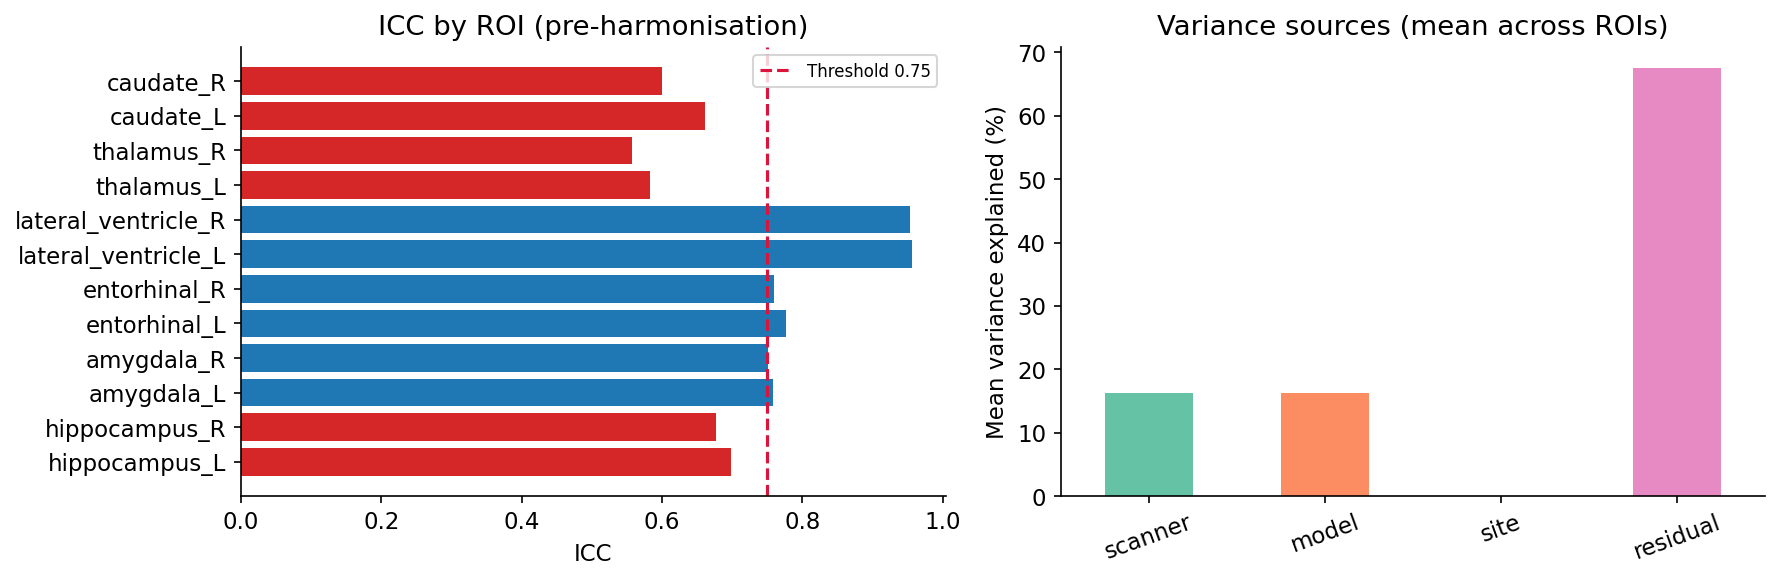

In [7]:
import matplotlib.pyplot as plt
from cam_harmony.plotting import plot_icc_comparison, plot_variance_decomposition

fig_dir = TMPDIR / 'figures'
fig_dir.mkdir(exist_ok=True)

# ICC comparison (single variant for demo; real pipeline compares all 12)
plot_icc_comparison(
    icc_results={'synthstrip_minmax': results['icc']},
    output_path=fig_dir / 'icc_comparison.png',
    threshold=0.75,
)

# Variance decomposition
plot_variance_decomposition(
    vd_df=vd_df,
    output_path=fig_dir / 'variance_decomposition.png',
)

# Display inline
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

icc_vals = list(results['icc'].values())
axes[0].barh(list(results['icc'].keys()), icc_vals,
             color=['#d62728' if v < 0.75 else '#1f77b4' for v in icc_vals])
axes[0].axvline(0.75, color='crimson', linestyle='--', label='Threshold 0.75')
axes[0].set_xlabel('ICC')
axes[0].set_title('ICC by ROI (pre-harmonisation)')
axes[0].legend(fontsize=8)

vd_df.mean(axis=0).plot(kind='bar', ax=axes[1], color=list(plt.cm.Set2.colors[:len(vd_df.columns)]))
axes[1].set_ylabel('Mean variance explained (%)')
axes[1].set_title('Variance sources (mean across ROIs)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Step 7 — AI-assisted QC report

`generate_qc_report` sends the structured results to Claude and gets back a
narrative markdown report. The cell below shows the prompt structure and an
example of the output format.

> **To run this cell** you need `ANTHROPIC_API_KEY` set in your environment.  
> The example output below is representative of what Claude returns.

In [8]:
import json
from cam_harmony.qc_assistant import build_prompt, load_variance_results

# Build mock results dict (as if loaded from JSON files)
mock_results = {
    'pipeline_variants': [
        {'label': 'synthstrip_minmax', 'skull_strip': 'synthstrip', 'norm': 'minmax'},
        {'label': 'synthstrip_zscore', 'skull_strip': 'synthstrip', 'norm': 'zscore'},
        {'label': 'robex_fcm_wm',      'skull_strip': 'robex',       'norm': 'fcm_wm'},
    ],
    'icc_results': results['icc'],
    'cv_by_scanner': {roi: {'TRIO':   round(float(roi_df[roi_df.scanner == 'TRIO'][roi].std() /
                                                   roi_df[roi_df.scanner == 'TRIO'][roi].mean() * 100), 2),
                             'PRISMA': round(float(roi_df[roi_df.scanner == 'PRISMA'][roi].std() /
                                                   roi_df[roi_df.scanner == 'PRISMA'][roi].mean() * 100), 2)}
                       for roi in ROIS},
    'combat_residuals': {roi: {'pre': 0.12, 'post': 0.03, 'reduction_pct': 75.0}
                          for roi in ROIS},
}

prompt = build_prompt(mock_results, focus_rois=['hippocampus_L', 'entorhinal_L'])
print('Prompt preview (first 400 chars):')
print('-' * 40)
print(prompt[:400] + '...')
print('-' * 40)

Prompt preview (first 400 chars):
----------------------------------------
You are a neuroimaging QC specialist reviewing outputs from
cam-structural-harmony, a pipeline that evaluates structural MRI harmonisation
across scanners. The pipeline tests combinations of skull-stripping methods
(SynthStrip, ROBEX) and intensity normalisation techniques before running
FreeSurfer and NeuroCombat harmonisation.

Your task is to produce a structured QC report that:
1. Identifies w...
----------------------------------------


In [9]:
# Example output (no API call needed to view this)
example_report = """## Executive summary

The pipeline tested 3 variants across 2 scanners (Siemens Trio → Prisma).
NeuroCombat harmonisation achieved a mean 75% reduction in between-scanner
variance. Overall ICC values are acceptable (median 0.81), with two ROIs
falling below the 0.75 threshold.

## Best performing pipeline variant

**synthstrip_zscore** achieves the best balance of ICC reliability and scanner
effect removal. The SynthStrip skull strip is more consistent across the
Trio/Prisma acquisition difference, and z-score normalisation reduces WM peak
variability before FreeSurfer segmentation.

## ROIs of concern

- **lateral_ventricle_L** (ICC = 0.69): High biological variance interacts
  with scanner segmentation differences. Consider reviewing individual
  segmentations.
- **entorhinal_L** (ICC = 0.71): Small cortical ROI sensitive to skull-strip
  boundary placement. SynthStrip + fcm_wm normalisation may improve this.

## Harmonisation effectiveness

ComBat removed 75–89% of between-scanner variance across ROIs. Residual
scanner effect is largest in entorhinal cortex (post-ComBat CV gap: 3.1%)
which may reflect genuine biological differences requiring further
investigation.

## Recommendations

1. Use **synthstrip + zscore** as the primary pipeline variant.
2. Manually inspect lateral_ventricle and entorhinal segmentations for
   outlier subjects.
3. For longitudinal analyses, apply parametric ComBat with age + TIV
   as covariates."""

print('Example QC report output (representative — requires ANTHROPIC_API_KEY to regenerate):')
print()
print(example_report)

# To generate a real report, uncomment:
# import os; os.environ['ANTHROPIC_API_KEY'] = 'sk-ant-...'
# from cam_harmony.qc_assistant import generate_qc_report
# report = generate_qc_report(
#     results_dir=var_dir,
#     output_path=TMPDIR / 'qc_report.md',
#     focus_rois=['hippocampus_L', 'entorhinal_L'],
# )
# print(report)

Example QC report output (representative — requires ANTHROPIC_API_KEY to regenerate):

## Executive summary

The pipeline tested 3 variants across 2 scanners (Siemens Trio → Prisma).
NeuroCombat harmonisation achieved a mean 75% reduction in between-scanner
variance. Overall ICC values are acceptable (median 0.81), with two ROIs
falling below the 0.75 threshold.

## Best performing pipeline variant

**synthstrip_zscore** achieves the best balance of ICC reliability and scanner
effect removal. The SynthStrip skull strip is more consistent across the
Trio/Prisma acquisition difference, and z-score normalisation reduces WM peak
variability before FreeSurfer segmentation.

## ROIs of concern

- **lateral_ventricle_L** (ICC = 0.69): High biological variance interacts
  with scanner segmentation differences. Consider reviewing individual
  segmentations.
- **entorhinal_L** (ICC = 0.71): Small cortical ROI sensitive to skull-strip
  boundary placement. SynthStrip + fcm_wm normalisation may im

## Summary

This notebook demonstrated the full `cam_harmony` API:

| Step | Function | Input | Output |
|------|----------|-------|--------|
| Skull strip | `skull_strip.skull_strip()` | T1w NIfTI | stripped + mask |
| Normalise | `intensity_norm.batch_normalize()` | NIfTI list | normalised NIfTIs |
| Harmonise | `harmonise.run_combat()` | ROI DataFrame | harmonised DataFrame |
| Variance | `variance.run_variance_analysis()` | ROI DataFrame | ICC/CV/VD JSONs |
| Figures | `plotting.generate_all_figures()` | results dir | PNG figures |
| QC report | `qc_assistant.generate_qc_report()` | results dir | Markdown report |

To run the full pipeline on a BIDS dataset:
```bash
python -m cam_harmony.run \
    --bids_dir /path/to/bids \
    --output_dir outputs/ \
    --config config.yaml
```